In [1]:
import os
import cv2
import shutil
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("trainingdatapro/real-vs-fake-anti-spoofing-video-classification")

print("Path to dataset files:", path)

100%|██████████| 3.04G/3.04G [03:02<00:00, 17.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/trainingdatapro/real-vs-fake-anti-spoofing-video-classification/versions/1


In [3]:
src = "/root/.cache/kagglehub/datasets/trainingdatapro/real-vs-fake-anti-spoofing-video-classification/versions/1"
dst = "./dataset"

shutil.copytree(src, dst, dirs_exist_ok=True)
print("Dataset extracted successfully.")

Dataset extracted successfully.


In [16]:
IMG_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 50
CLASS_WEIGHT = {0: 1.0, 1: 1.2}

DATASET_PATH = "./dataset"

VIDEO_EXT = (".mp4", ".avi", ".mov", ".mkv")

LABEL_MAP = {
    "attack": 0,
    "real_video": 1
}

In [5]:
def extract_frames(video_path, max_frames=8, stride=3):
    frames = []

    cap = cv2.VideoCapture(video_path)
    frame_idx = 0

    while cap.isOpened() and len(frames) < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % stride == 0:
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            frame = frame.astype("float32") / 255.0
            frames.append(frame)

        frame_idx += 1

    cap.release()
    return frames

In [6]:
def load_split(split):
    images = []
    labels = []

    split_path = os.path.join(DATASET_PATH, split)

    print(f"\nLoading {split}...")

    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)

        if not os.path.isdir(class_path):
            continue

        if class_name not in LABEL_MAP:
            continue

        label = LABEL_MAP[class_name]

        print(f"Processing: {split}/{class_name} -> label {label}")

        for file in os.listdir(class_path):
            file_path = os.path.join(class_path, file)

            try:
                # IMAGE
                if file.lower().endswith((".jpg", ".jpeg", ".png")):
                    img = cv2.imread(file_path)
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    img = img.astype("float32") / 255.0

                    images.append(img)
                    labels.append(label)

                # VIDEO
                elif file.lower().endswith(VIDEO_EXT):
                    frames = extract_frames(file_path)

                    for frame in frames:
                        images.append(frame)
                        labels.append(label)

            except Exception as e:
                print("Skipping:", file_path, e)

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)

    print("Class distribution:", np.unique(labels, return_counts=True))

    return images, labels
    return np.array(images), np.array(labels)

In [7]:
X, y = load_split("train")

print("\nTotal samples:", len(X))


Loading train...
Processing: train/attack -> label 0
Processing: train/real_video -> label 1
Class distribution: (array([0, 1], dtype=int32), array([440, 440]))

Total samples: 880


In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
model = Sequential([

    Conv2D(32, (3,3), activation="relu", input_shape=(64, 64, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),

    Dense(96, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

In [29]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,729 (413.00 KB)

 Trainable params: 105,729 (413.00 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHT,
    shuffle=True
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.5227 - loss: 0.7524 - val_accuracy: 0.5000 - val_loss: 0.6847
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5625 - loss: 0.7326 - val_accuracy: 0.5227 - val_loss: 0.6681
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6520 - loss: 0.6997 - val_accuracy: 0.7500 - val_loss: 0.6274
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7557 - loss: 0.6590 - val_accuracy: 0.8295 - val_loss: 0.5798
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7969 - loss: 0.6022 - val_accuracy: 0.7955 - val_loss: 0.5423
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8281 - loss: 0.5367 - val_accuracy: 0.8352 - val_loss: 0.4824
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8281 - loss: 0.4849 - val_accuracy: 0.8409 - val_loss: 0.4483
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8509 - loss: 0.4569 - val_accuracy: 0.8239 - v

In [33]:
model.save("anti_spoof_model.keras")

print("Done.")

Done.


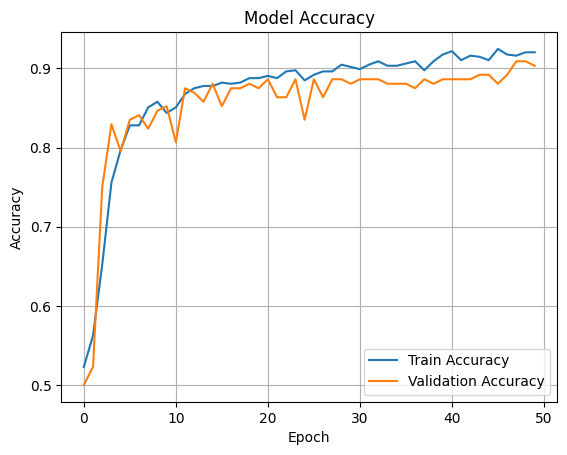

In [31]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

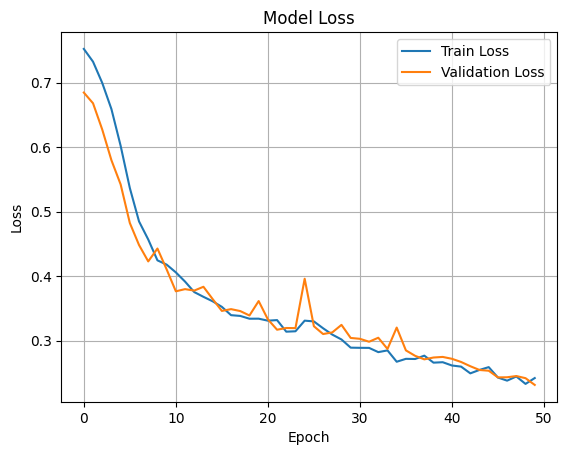

In [32]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()